In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from pandas.plotting import autocorrelation_plot


sns.set(style="whitegrid")

In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")


plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 12
})

In [5]:
small = pd.read_csv("data/BSESML_01032016_16032026.csv")
mid = pd.read_csv("data/BSEMID_01032016_16032026.csv")
large = pd.read_csv("data/SPBSLIP_01032016_16032026.csv")

In [6]:
# DATA CLEANING
datasets = [small, mid, large]

for df in datasets:
    # Convert Date column
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Sort data
    df.sort_values(by='Date', inplace=True)
    
    # Reset index
    df.reset_index(drop=True, inplace=True)

In [7]:
# CHECK MISSING VALUES
for name, df in zip(['Small','Mid','Large'], datasets):
    print(name, "Missing Values:\n", df.isnull().sum(), "\n")


Small Missing Values:
 Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64 

Mid Missing Values:
 Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64 

Large Missing Values:
 Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64 



In [8]:
# HANDLE

for df in datasets:
    df.ffill(inplace=True)

In [9]:
# CHECK DUPLICATES

for name, df in zip(['Small','Mid','Large'], datasets):
    print(name, "Duplicate Rows:", df.duplicated().sum())

Small Duplicate Rows: 0
Mid Duplicate Rows: 0
Large Duplicate Rows: 0


In [10]:
# REMOVE DUPLICATES
for df in datasets:
    df.drop_duplicates(inplace=True)

In [11]:
for name, df in zip(['Small','Mid','Large'], datasets):
    print(name, "Shape:", df.shape)

Small Shape: (2488, 5)
Mid Shape: (2488, 5)
Large Shape: (2488, 5)


In [12]:
# DATA MERGING

# Select required columns
large_df = large[['Date','Close']].rename(columns={'Close':'Large'})
mid_df = mid[['Date','Close']].rename(columns={'Close':'Mid'})
small_df = small[['Date','Close']].rename(columns={'Close':'Small'})

# Merge datasets
combined = large_df.merge(mid_df, on='Date').merge(small_df, on='Date')


combined.head()

,Date,Large,Mid,Small
0,2016-03-01,2784.44,9866.27,9856.56
1,2016-03-02,2838.55,10051.86,10073.97
2,2016-03-03,2878.78,10110.46,10209.66
3,2016-03-04,2884.35,10224.84,10285.75
4,2016-03-08,2886.76,10199.44,10309.98


In [13]:
# CALCULATE RETURNS

combined['Large_Return'] = combined['Large'].pct_change()
combined['Mid_Return'] = combined['Mid'].pct_change()
combined['Small_Return'] = combined['Small'].pct_change()

combined.head()

,Date,Large,Mid,Small,Large_Return,Mid_Return,Small_Return
0,2016-03-01,2784.44,9866.27,9856.56,NaN,NaN,NaN
1,2016-03-02,2838.55,10051.86,10073.97,0.019433,0.018811,0.022057
2,2016-03-03,2878.78,10110.46,10209.66,0.014173,0.005830,0.013469
3,2016-03-04,2884.35,10224.84,10285.75,0.001935,0.011313,0.007453
4,2016-03-08,2886.76,10199.44,10309.98,0.000836,-0.002484,0.002356


In [14]:
# BASIC EDA
print("Shape:", combined.shape)
print("\nData Types:\n", combined.dtypes)
combined.describe()

Shape: (2488, 7)

Data Types:
 Date            datetime64[ns]
Large                  float64
Mid                    float64
Small                  float64
Large_Return           float64
Mid_Return             float64
Small_Return           float64
dtype: object


,Date,Large,Mid,Small,Large_Return,Mid_Return,Small_Return
count,2488,2488.000000,2488.000000,2488.000000,2487.000000,2487.000000,2487.000000
mean,2021-03-11 01:48:48.617363456,5973.005109,24261.706005,26628.360904,0.000527,0.000645,0.000678
min,2016-03-01 00:00:00,2784.440000,9711.440000,8872.830000,-0.129416,-0.128345,-0.122662
25%,2018-09-03 18:00:00,4116.290000,14795.642500,14437.267500,-0.004116,-0.004544,-0.004423
50%,2021-03-09 12:00:00,5653.760000,20081.800000,20550.200000,0.000832,0.001794,0.002163
75%,2023-09-12 06:00:00,7428.852500,31454.572500,37047.182500,0.005720,0.006911,0.007142
max,2026-03-16 00:00:00,10227.300000,49621.690000,57703.480000,0.085965,0.062831,0.041757
std,NaN,2203.050605,12043.740976,14656.744350,0.010140,0.011191,0.011560


In [15]:
# CORRELATION
combined[['Large','Mid','Small']].corr()

,Large,Mid,Small
Large,1.000000,0.978275,0.977152
Mid,0.978275,1.000000,0.997072
Small,0.977152,0.997072,1.000000


In [16]:
# COVARIANCE

combined[['Large','Mid','Small']].cov()

,Large,Mid,Small
Large,4.853432e+06,2.595654e+07,3.155181e+07
Mid,2.595654e+07,1.450517e+08,1.760052e+08
Small,3.155181e+07,1.760052e+08,2.148202e+08


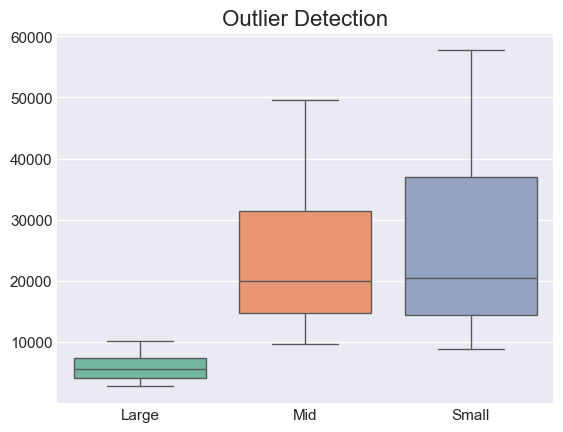

In [17]:
# OUTLIER DETECTION

sns.boxplot(data=combined[['Large','Mid','Small']])
plt.title("Outlier Detection")
plt.show()

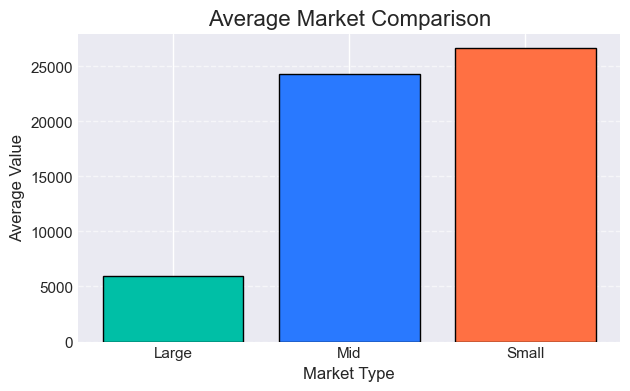

In [18]:
# Bar graph 
plt.figure(figsize=(7,4))

colors = ['#00BFA6', '#2979FF', '#FF7043']

avg_values = [combined['Large'].mean(), combined['Mid'].mean(), combined['Small'].mean()]
labels = ['Large','Mid','Small']

plt.bar(labels, avg_values, color=colors, edgecolor='black')

plt.title("Average Market Comparison")
plt.xlabel("Market Type")
plt.ylabel("Average Value")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

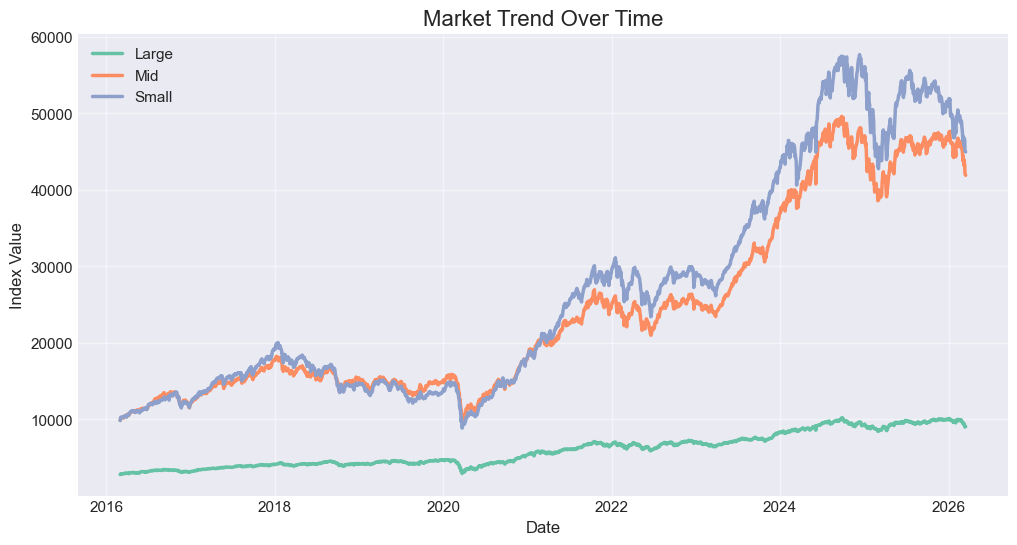

In [19]:
# Line plot
plt.figure(figsize=(12,6))

plt.plot(combined['Date'], combined['Large'], label='Large', linewidth=2.5)
plt.plot(combined['Date'], combined['Mid'], label='Mid', linewidth=2.5)
plt.plot(combined['Date'], combined['Small'], label='Small', linewidth=2.5)

plt.legend()
plt.title("Market Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.grid(alpha=0.5)
plt.show()

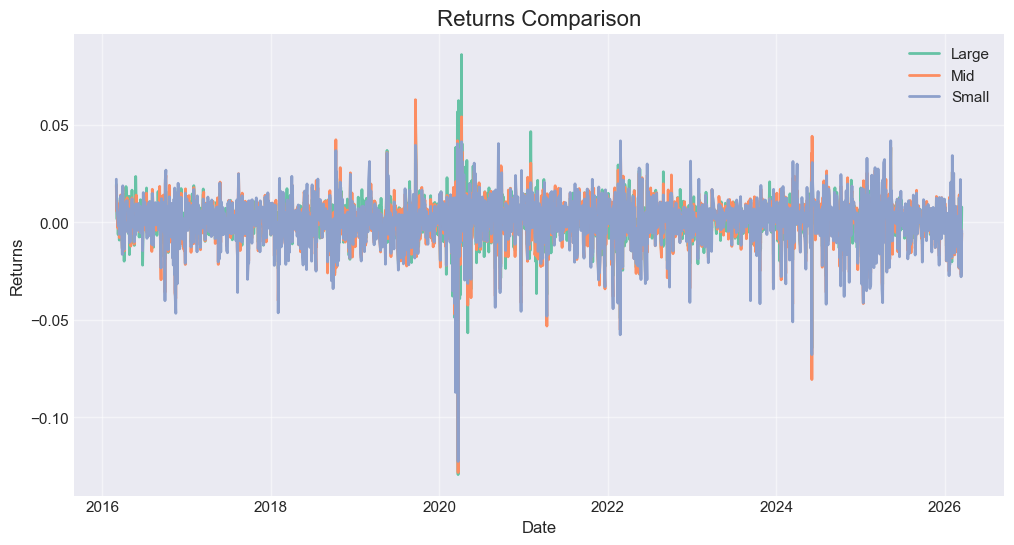

In [20]:
# Line 
plt.figure(figsize=(12,6))

plt.plot(combined['Date'], combined['Large_Return'], label='Large', linewidth=2)
plt.plot(combined['Date'], combined['Mid_Return'], label='Mid', linewidth=2)
plt.plot(combined['Date'], combined['Small_Return'], label='Small', linewidth=2)

plt.legend()
plt.title("Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Returns")

plt.grid(alpha=0.5)
plt.show()

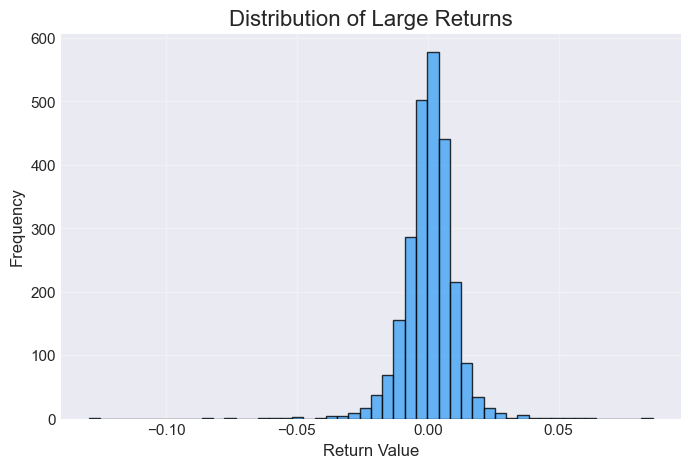

In [21]:
# Histogram 
plt.figure(figsize=(8,5))

plt.hist(combined['Large_Return'].dropna(),
         bins=50,
         color='#42A5F5',
         edgecolor='black',
         alpha=0.8)

plt.title("Distribution of Large Returns")
plt.xlabel("Return Value")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

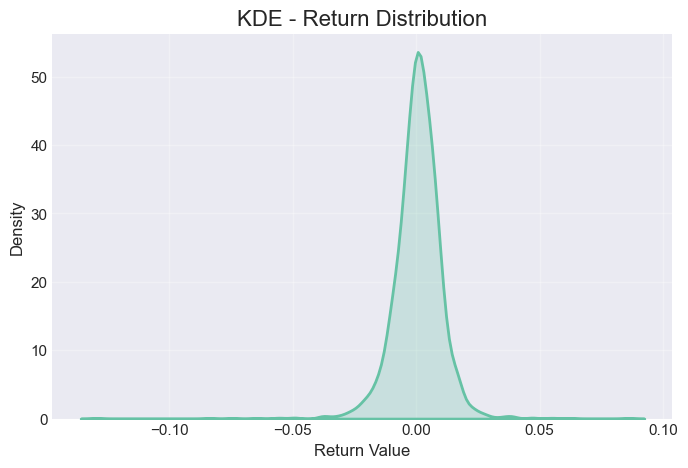

In [22]:
# KDE plot 
plt.figure(figsize=(8,5))

sns.kdeplot(combined['Large_Return'].dropna(),
            fill=True,
            linewidth=2)

plt.title("KDE - Return Distribution")
plt.xlabel("Return Value")

plt.grid(alpha=0.3)
plt.show()

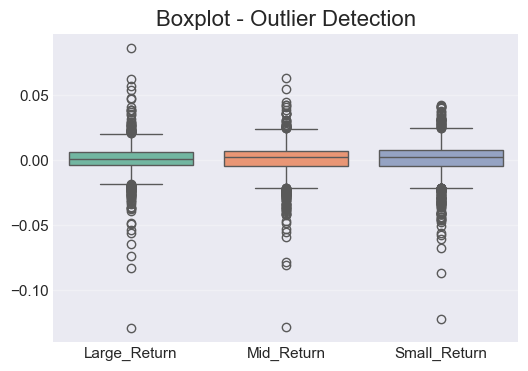

In [23]:
# Boxplot 
plt.figure(figsize=(6,4))

sns.boxplot(data=combined[['Large_Return','Mid_Return','Small_Return']],
            palette="Set2")

plt.title("Boxplot - Outlier Detection")
plt.grid(axis='y', alpha=0.3)
plt.show()

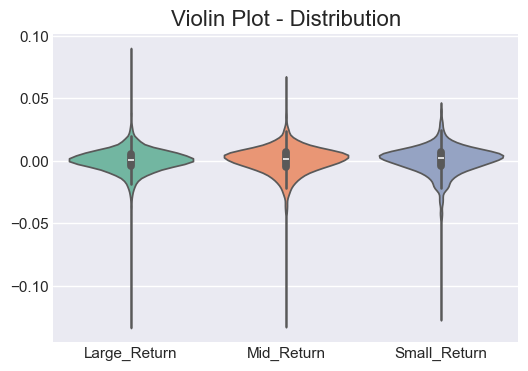

In [24]:
# Violin plot 
plt.figure(figsize=(6,4))

sns.violinplot(data=combined[['Large_Return','Mid_Return','Small_Return']],
               palette="Set2")

plt.title("Violin Plot - Distribution")
plt.show()

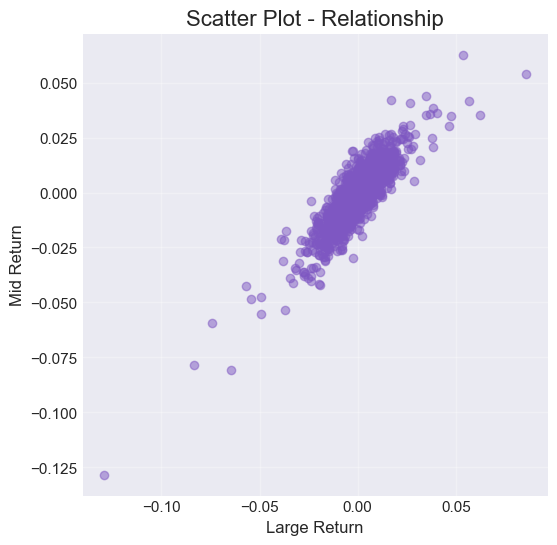

In [25]:
# Scatter plot 
plt.figure(figsize=(6,6))

plt.scatter(combined['Large_Return'],
            combined['Mid_Return'],
            alpha=0.5,
            color='#7E57C2')

plt.xlabel("Large Return")
plt.ylabel("Mid Return")
plt.title("Scatter Plot - Relationship")

plt.grid(alpha=0.3)
plt.show()

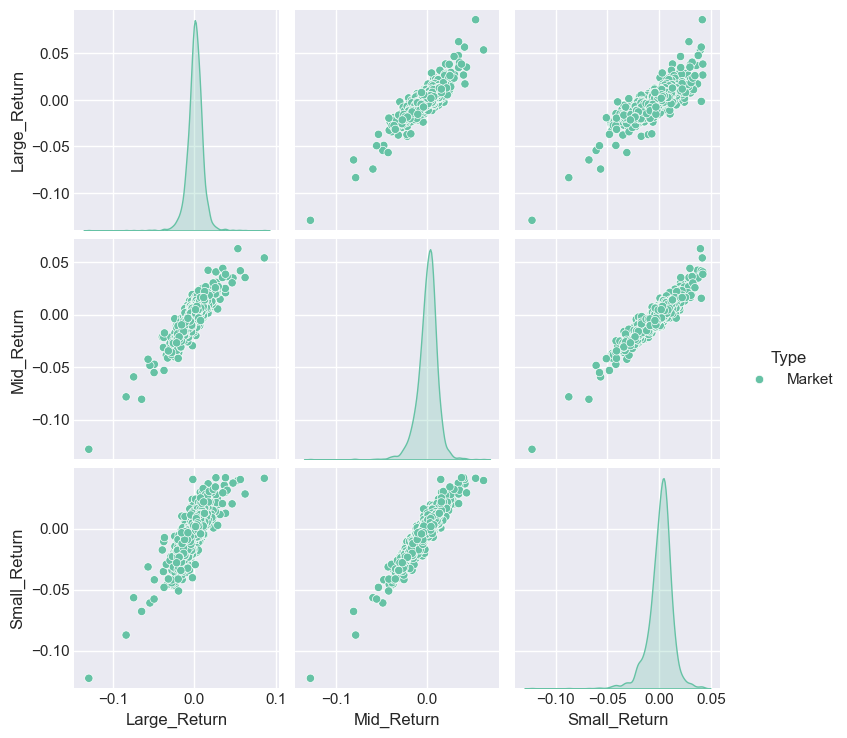

In [26]:
# Pairplot


df_pair = combined[['Large_Return','Mid_Return','Small_Return']].copy()

df_pair['Type'] = 'Market' 

sns.pairplot(df_pair, hue='Type')

plt.show()

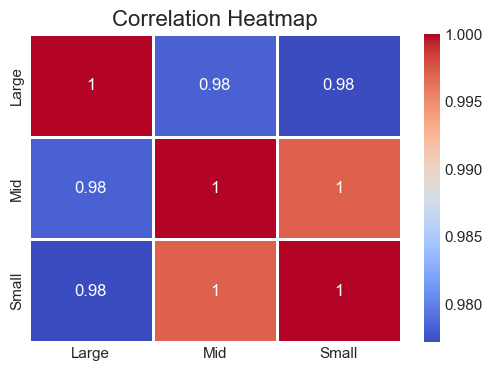

In [27]:
# Heatmap 
plt.figure(figsize=(6,4))

sns.heatmap(combined[['Large','Mid','Small']].corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=1)

plt.title("Correlation Heatmap")
plt.show()

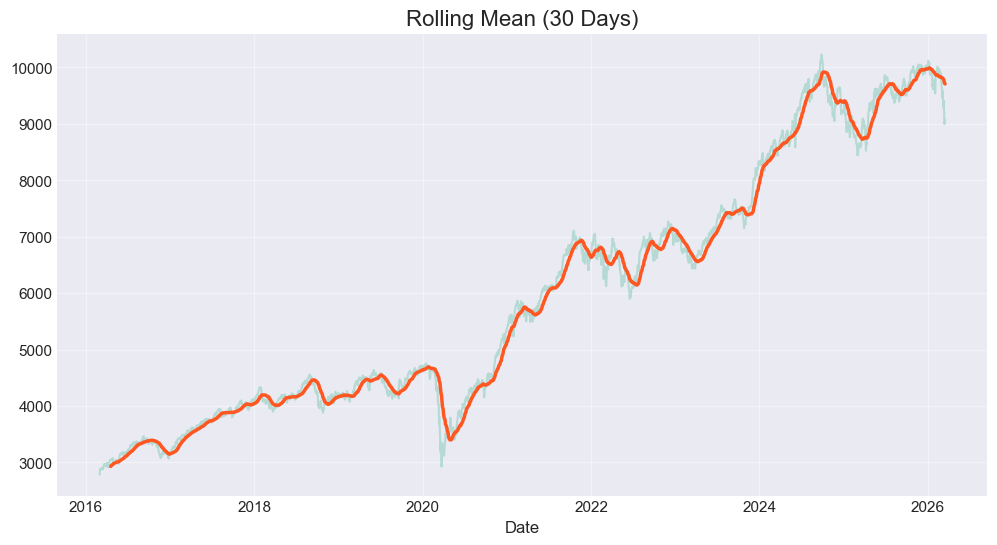

In [28]:
# Rolling mean 
rolling = combined['Large'].rolling(30).mean()

plt.figure(figsize=(12,6))

plt.plot(combined['Date'], combined['Large'], alpha=0.4)
plt.plot(combined['Date'], rolling, linewidth=2.5, color='#FF5722')

plt.title("Rolling Mean (30 Days)")
plt.xlabel("Date")

plt.grid(alpha=0.4)
plt.show()

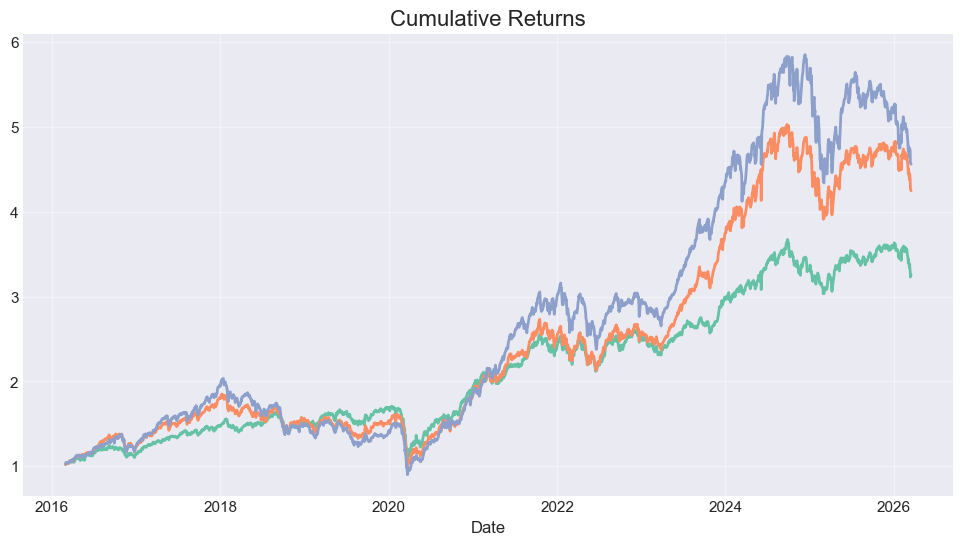

In [29]:
# Cumulative returns 
cum = (1 + combined[['Large_Return','Mid_Return','Small_Return']]).cumprod()

plt.figure(figsize=(12,6))

plt.plot(combined['Date'], cum['Large_Return'], linewidth=2)
plt.plot(combined['Date'], cum['Mid_Return'], linewidth=2)
plt.plot(combined['Date'], cum['Small_Return'], linewidth=2)

plt.title("Cumulative Returns")
plt.xlabel("Date")

plt.grid(alpha=0.4)
plt.show()

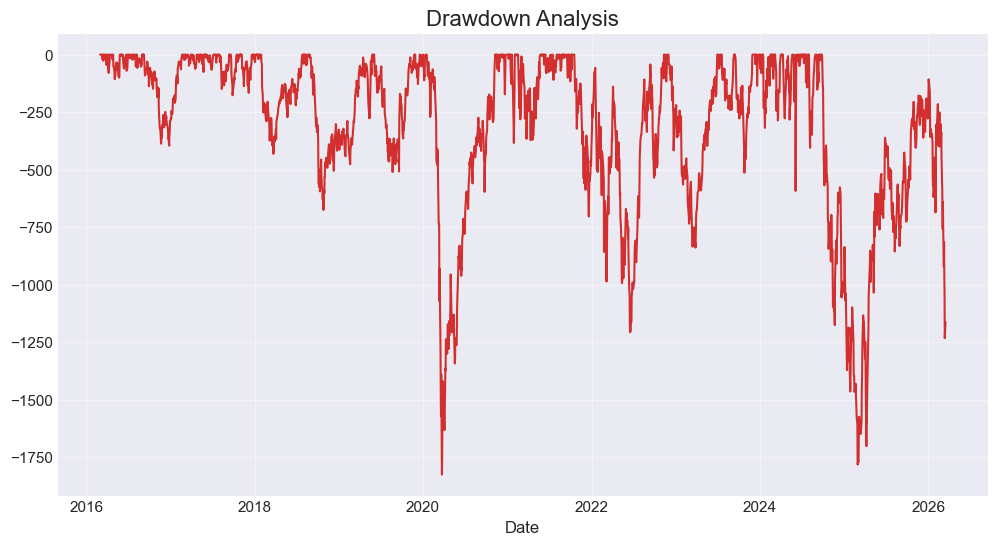

In [30]:
# Drawdown 
drawdown = combined['Large'] - combined['Large'].cummax()

plt.figure(figsize=(12,6))

plt.plot(combined['Date'], drawdown, color='#D32F2F')

plt.title("Drawdown Analysis")
plt.xlabel("Date")

plt.grid(alpha=0.4)
plt.show()

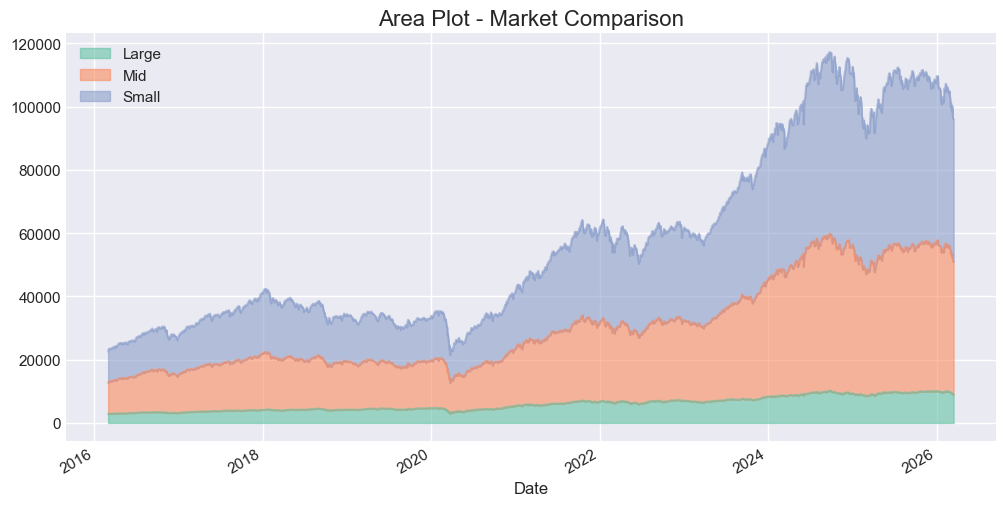

In [32]:
# Area plot 
combined.set_index('Date')[['Large','Mid','Small']].plot.area(
    figsize=(12,6),
    alpha=0.6
)

plt.title("Area Plot - Market Comparison")
plt.show()

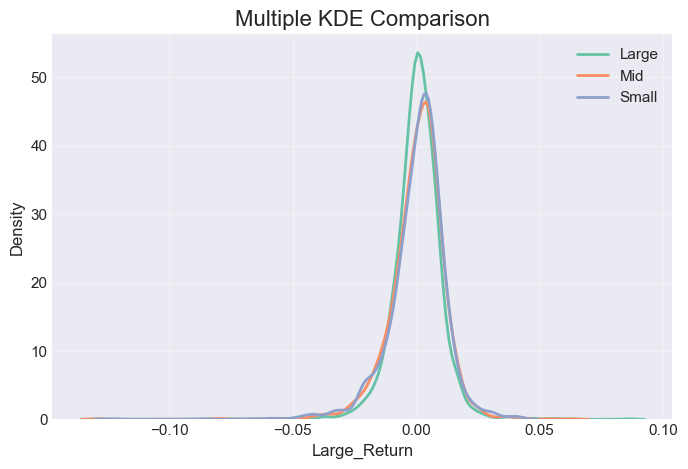

In [33]:
# Multiple KDE 
plt.figure(figsize=(8,5))

sns.kdeplot(combined['Large_Return'].dropna(), label='Large', linewidth=2)
sns.kdeplot(combined['Mid_Return'].dropna(), label='Mid', linewidth=2)
sns.kdeplot(combined['Small_Return'].dropna(), label='Small', linewidth=2)

plt.legend()
plt.title("Multiple KDE Comparison")
plt.grid(alpha=0.3)
plt.show()

[Large Cap]  R² = 0.8668   RMSE = 152.54
[Mid   Cap]  R² = 0.8438   RMSE = 991.98
[Small Cap]  R² = 0.8528   RMSE = 1379.50

Future Predictions

Large Cap  |  Last actual close : 9064.25
Large Cap  |  Predicted day +30 : 9149.07

Mid Cap  |  Last actual close : 41916.42
Mid Cap  |  Predicted day +30 : 42794.78

Small Cap  |  Last actual close : 44970.31
Small Cap  |  Predicted day +30 : 45846.13


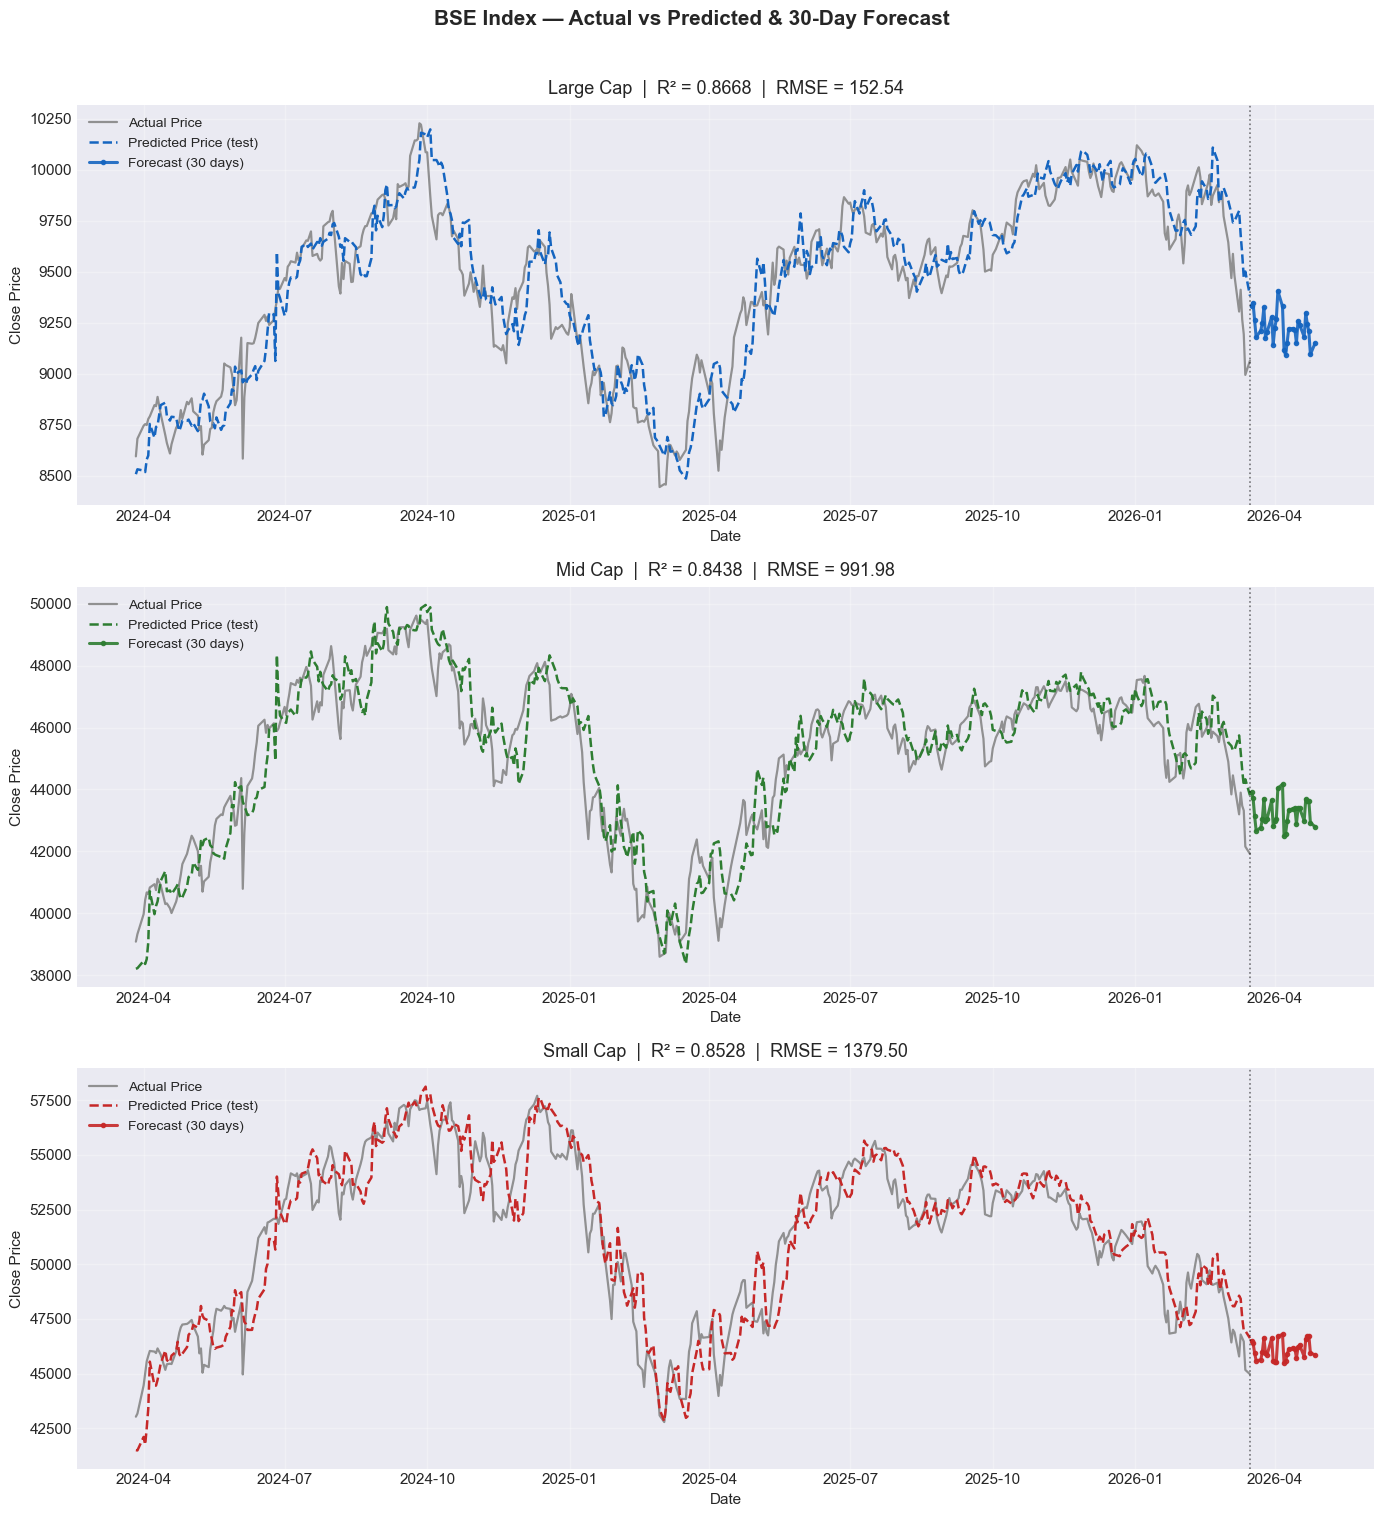

In [55]:

# ML MODEL — LINEAR REGRESSION

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Feature Engineering 
def create_lr_features(df):
    d = df[['Date', 'Close']].copy()
    d['Date'] = pd.to_datetime(d['Date'], dayfirst=True, errors='coerce')
    d = d.sort_values('Date').reset_index(drop=True)

    # Moderate lags on PRICE (not returns) — 15 to 45 days back
    d['Lag_15']       = d['Close'].shift(15)
    d['Lag_30']       = d['Close'].shift(30)
    d['Lag_45']       = d['Close'].shift(45)

    # Medium rolling windows
    d['Roll_Mean_20'] = d['Close'].rolling(20).mean()
    d['Roll_Std_20']  = d['Close'].rolling(20).std()
    d['Roll_Mean_40'] = d['Close'].rolling(40).mean()

    # Calendar features (noise)
    d['DayOfWeek']    = d['Date'].dt.dayofweek
    d['Month']        = d['Date'].dt.month

    d.dropna(inplace=True)
    return d

# Train, Predict & Score 
lr_results = {}
FEATURES = ['Lag_15', 'Lag_30', 'Lag_45',
            'Roll_Mean_20', 'Roll_Std_20', 'Roll_Mean_40',
            'DayOfWeek', 'Month']

for name, df in zip(['Large', 'Mid', 'Small'],
                    [large,   mid,   small]):

    feat_df = create_lr_features(df)

    X     = feat_df[FEATURES].values
    y     = feat_df['Close'].values
    dates = feat_df['Date'].values

    # Chronological 80/20 split
    split           = int(len(X) * 0.80)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    dates_test      = dates[split:]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    lr_results[name] = {
        'feat_df'   : feat_df,
        'dates_test': dates_test,
        'actual'    : y_test,
        'predicted' : y_pred,
        'r2'        : r2,
        'rmse'      : rmse,
        'model'     : model,
        'split'     : split,
    }

    print(f"[{name:5s} Cap]  R² = {r2:.4f}   RMSE = {rmse:.2f}")

# Future 30-Day Forecast 
print("\nFuture Predictions")

for name, df in zip(['Large', 'Mid', 'Small'],
                    [large,   mid,   small]):

    feat_df = lr_results[name]['feat_df']
    model   = lr_results[name]['model']

    future_dates  = pd.bdate_range(
        start=feat_df['Date'].iloc[-1] + pd.Timedelta(days=1),
        periods=30
    )

    recent_closes = list(feat_df['Close'].values[-45:])
    future_preds  = []

    for fd in future_dates:
        lag15 = recent_closes[-15]
        lag30 = recent_closes[-30]
        lag45 = recent_closes[-45]
        rmean20 = np.mean(recent_closes[-20:])
        rstd20  = np.std(recent_closes[-20:])
        rmean40 = np.mean(recent_closes[-40:])
        dow     = fd.dayofweek
        mon     = fd.month

        pred = model.predict([[lag15, lag30, lag45,
                               rmean20, rstd20, rmean40,
                               dow, mon]])[0]
        future_preds.append(pred)
        recent_closes.append(pred)
        recent_closes.pop(0)

    lr_results[name]['future_dates'] = future_dates
    lr_results[name]['future_preds'] = future_preds

    print(f"\n{name} Cap  |  Last actual close : {feat_df['Close'].iloc[-1]:.2f}")
    print(f"{name} Cap  |  Predicted day +30 : {future_preds[-1]:.2f}")


colors = {'Large': '#1565C0', 'Mid': '#2E7D32', 'Small': '#C62828'}

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle("BSE Index — Actual vs Predicted & 30-Day Forecast",
             fontsize=15, fontweight='bold', y=1.01)

for ax, name in zip(axes, ['Large', 'Mid', 'Small']):
    res = lr_results[name]

    ax.plot(res['dates_test'], res['actual'],
            color='grey', linewidth=1.6, alpha=0.85, label='Actual Price')

    ax.plot(res['dates_test'], res['predicted'],
            color=colors[name], linewidth=1.8,
            linestyle='--', label='Predicted Price (test)')

    ax.plot(res['future_dates'], res['future_preds'],
            color=colors[name], linewidth=2.2,
            linestyle='-', marker='o', markersize=3,
            alpha=0.9, label='Forecast (30 days)')

    ax.axvline(x=res['dates_test'][-1], color='black',
               linestyle=':', linewidth=1.2, alpha=0.5)

    ax.set_title(
        f"{name} Cap  |  R² = {res['r2']:.4f}  |  RMSE = {res['rmse']:.2f}",
        fontsize=13, pad=8
    )
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Close Price", fontsize=11)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
import os
os.getcwd()

'C:\\Users\\rpkga\\Desktop\\Untitled Folder\\python_project'